In [1]:
# [setup]
# Weekly seasonality of the most recent September mobile model, assembled to
# world DAU from the 64 country x app tiles' fitted Prophet objects.
#
# Mobile tiles are fit in RAW DAU (no log transform, logistic growth).  63 tiles
# use multiplicative seasonality, where  yhat = trend * (1 + weekly_recent + ...),
# so the weekly term in DAU is  trend * weekly_recent;  the one additive tile
# (ROW Fenix, above the 2e6 volume switch) has  yhat = trend + weekly_recent + ...,
# so the weekly term is already DAU.  Either way the DAU-space effect is
# yhat - (yhat - weekly_dau) with no exp(), so unlike desktop there is no Jensen gap.
#
# Caveat: under the `p` split the Fenix tiles are fit on ORGANIC DAU; the paid
# level is stacked back on after mozaic and carries no modelled weekly pattern.
# The model-side world here is therefore organic mobile, not the published total.
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib.externals import cloudpickle

BUILD_DIR = (
    "mobile_cpr0725_paid0915med_2026-09-09/"   # Med paid scenario (c-suite, 2026-09-15); Prophet tiles identical to the Low build
    "cps0.035_thresh055_recent13_cpr0.725_ncp25_clip0.6_sps0.1"
)
PKL_PATH = f"{BUILD_DIR}/mozaic_objects.glean_mobile.2026-09-09.pkl"
FORECAST_START = pd.Timestamp("2026-09-09")
HORIZON_END = pd.Timestamp("2026-12-29")   # 16 whole weeks from the seam, so day-of-week means are balanced
PLOT_PATH = "plots/mobile_weekly_seasonality_2026-09-09.png"
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

with open(PKL_PATH, "rb") as f:
    mozaic_by_metric = cloudpickle.load(f)
tiles = mozaic_by_metric["DAU"].tiles
modes = pd.Series([t._prophet_model.seasonality_mode for t in tiles]).value_counts()
print(f"Loaded {len(tiles)} tiles from {PKL_PATH}; seasonality modes: {modes.to_dict()}")


Loaded 64 tiles from mobile_cpr0725_paid0915med_2026-09-09/cps0.035_thresh055_recent13_cpr0.725_ncp25_clip0.6_sps0.1/mozaic_objects.glean_mobile.2026-09-09.pkl; seasonality modes: {'multiplicative': 63, 'additive': 1}


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [weekly-dau-by-tile]
# Per-tile DAU weekly effect over the horizon, summed to the world, then averaged
# by day of week.  Two definitions side by side, as for desktop:
#   trend-referenced : DAU with the weekly term minus DAU without it (the model's own
#                      decomposition).  In raw-DAU space this should average to ~0.
#   mean-referenced  : world DAU minus its centered 7-day rolling mean.  Zero-mean by
#                      construction.
horizon_rows = []
for tile in tiles:
    fitted = tile._prophet_forecast
    in_horizon = (fitted["ds"] >= FORECAST_START) & (fitted["ds"] <= HORIZON_END)
    frame = fitted.loc[in_horizon, ["ds", "trend", "weekly_recent", "yhat"]].copy()
    if tile._prophet_model.seasonality_mode == "multiplicative":
        frame["weekly_dau"] = frame["trend"] * frame["weekly_recent"]
    else:
        frame["weekly_dau"] = frame["weekly_recent"]
    frame["tile"] = tile.name
    frame["dau"] = frame["yhat"]
    horizon_rows.append(frame[["ds", "tile", "dau", "weekly_dau", "weekly_recent"]])
tile_daily = pd.concat(horizon_rows, ignore_index=True)

world_daily = tile_daily.groupby("ds", as_index=True)[["dau", "weekly_dau"]].sum()
world_daily["dow"] = world_daily.index.dayofweek
world_daily["dev_from_7d_mean"] = (
    world_daily["dau"] - world_daily["dau"].rolling(7, center=True).mean()
)
world_level = world_daily["dau"].mean()

by_dow = pd.DataFrame({
    "trend_referenced": world_daily.groupby("dow")["weekly_dau"].mean(),
    "mean_referenced": world_daily.groupby("dow")["dev_from_7d_mean"].mean(),
}).reindex(range(7))
by_dow.index = DOW_LABELS

fourier_mean = tile_daily["weekly_recent"].mean()
means = {
    "Fourier term, native units (all tiles)": fourier_mean,
    "DAU trend-referenced, mean of 7 day-of-week values": by_dow["trend_referenced"].mean(),
    "DAU trend-referenced, mean over every horizon day": world_daily["weekly_dau"].mean(),
    "DAU mean-referenced, mean of 7 day-of-week values": by_dow["mean_referenced"].mean(),
}
assert (len(world_daily) % 7) == 0, f"horizon is {len(world_daily)} days, not whole weeks"
assert abs(fourier_mean) < 1e-9, f"Fourier weekly term should average to 0, got {fourier_mean:.3e}"

print(f"Horizon {FORECAST_START.date()} .. {HORIZON_END.date()}, {len(world_daily)} days "
      f"({len(world_daily) // 7} whole weeks), organic-mobile world mean level {world_level:,.0f} DAU")
print("Weekly effect by day of week (world, DAU):")
print(f"  {'':4} {'trend-referenced':>18} {'':>9} {'mean-referenced':>18} {'':>9}")
for label, row in by_dow.iterrows():
    print(f"  {label:4} {row.trend_referenced:>+18,.0f} ({row.trend_referenced / world_level:+.1%}) "
          f"{row.mean_referenced:>+18,.0f} ({row.mean_referenced / world_level:+.1%})")
print("Means:")
for name, value in means.items():
    unit = "" if "native" in name else f"  ({value / world_level:+.3%} of level)"
    print(f"  {name:55s} {value:>+14,.4f}{unit}")


Horizon 2026-09-09 .. 2026-12-29, 112 days (16 whole weeks), organic-mobile world mean level 15,882,886 DAU
Weekly effect by day of week (world, DAU):
         trend-referenced              mean-referenced          
  Mon            +199,019 (+1.3%)           +199,082 (+1.3%)
  Tue            +261,701 (+1.6%)           +261,721 (+1.6%)
  Wed            +231,971 (+1.5%)           +232,249 (+1.5%)
  Thu            +176,643 (+1.1%)           +176,874 (+1.1%)
  Fri             +32,158 (+0.2%)            +32,229 (+0.2%)
  Sat            -436,200 (-2.7%)           -436,130 (-2.7%)
  Sun            -465,278 (-2.9%)           -464,892 (-2.9%)
Means:
  Fourier term, native units (all tiles)                         +0.0000
  DAU trend-referenced, mean of 7 day-of-week values             +2.1413  (+0.000% of level)
  DAU trend-referenced, mean over every horizon day              +2.1413  (+0.000% of level)
  DAU mean-referenced, mean of 7 day-of-week values            +161.8465  (+0.001% of level

saved plots/mobile_weekly_seasonality_2026-09-09.png


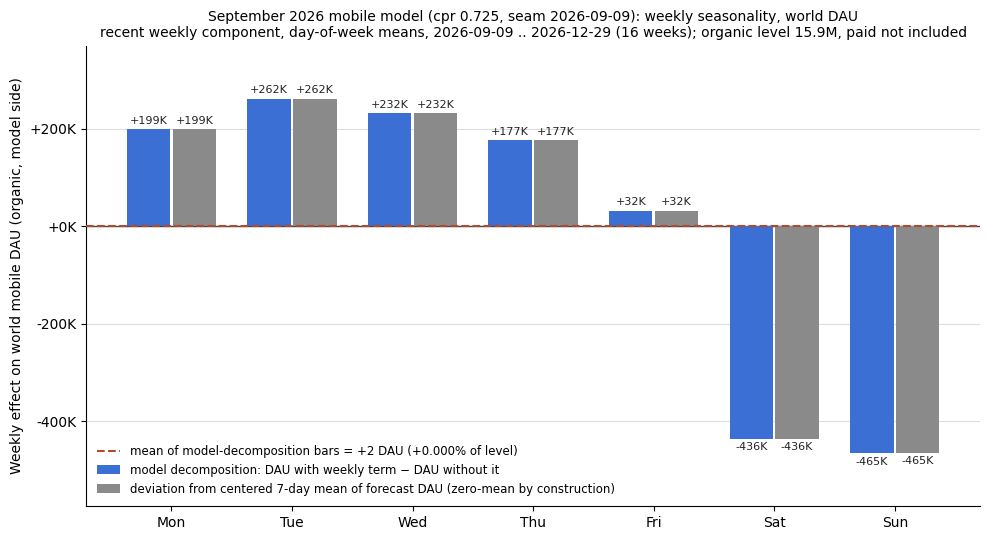

In [3]:
# [plot-mobile-weekly]
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(7)
width = 0.38
colors = {"trend_referenced": "#3B6FD4", "mean_referenced": "#8A8A8A"}
labels = {
    "trend_referenced": "model decomposition: DAU with weekly term − DAU without it",
    "mean_referenced": "deviation from centered 7-day mean of forecast DAU (zero-mean by construction)",
}
for i, key in enumerate(["trend_referenced", "mean_referenced"]):
    ax.bar(x + (i - 0.5) * width, by_dow[key].values, width=width - 0.02,
           color=colors[key], label=labels[key], zorder=3)
ax.axhline(0, color="#444444", linewidth=1.0, zorder=2)
trend_mean = by_dow["trend_referenced"].mean()
ax.axhline(trend_mean, color="#B04A2E", linewidth=1.5, linestyle="--", zorder=4,
           label=f"mean of model-decomposition bars = {trend_mean:+,.0f} DAU "
                 f"({trend_mean / world_level:+.3%} of level)")
label_offset = 0.015 * np.abs(by_dow.values).max()
for i, key in enumerate(["trend_referenced", "mean_referenced"]):
    for xi, value in zip(x + (i - 0.5) * width, by_dow[key].values):
        ax.text(xi, value + (label_offset if value >= 0 else -label_offset), f"{value / 1e3:+.0f}K",
                ha="center", va="bottom" if value >= 0 else "top", fontsize=8, color="#222222")
ax.set_xticks(x, DOW_LABELS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e3:+.0f}K"))
ax.set_ylabel("Weekly effect on world mobile DAU (organic, model side)")
ax.set_title("September 2026 mobile model (cpr 0.725, seam 2026-09-09): weekly seasonality, world DAU\n"
             f"recent weekly component, day-of-week means, {FORECAST_START.date()} .. {HORIZON_END.date()} "
             f"({len(world_daily) // 7} weeks); organic level {world_level / 1e6:.1f}M, paid not included",
             fontsize=10)
ax.grid(axis="y", color="#DDDDDD", zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(y=0.15)
ax.legend(loc="lower left", frameon=False, fontsize=8.5)
fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=150)
print(f"saved {PLOT_PATH}")
plt.show()


Actuals 2026-07-12 .. 2026-09-05 (8 whole weeks), world mean level 17,226,259 DAU
  Mon      +213,130   (+1.2%)
  Tue      +259,583   (+1.5%)
  Wed      +229,327   (+1.3%)
  Thu      +178,782   (+1.0%)
  Fri       +41,802   (+0.2%)
  Sat      -442,469   (-2.6%)
  Sun      -485,678   (-2.8%)
mean over 7 day-of-week values:         -789


saved plots/mobile_weekly_seasonality_actuals_2026-09-05.png


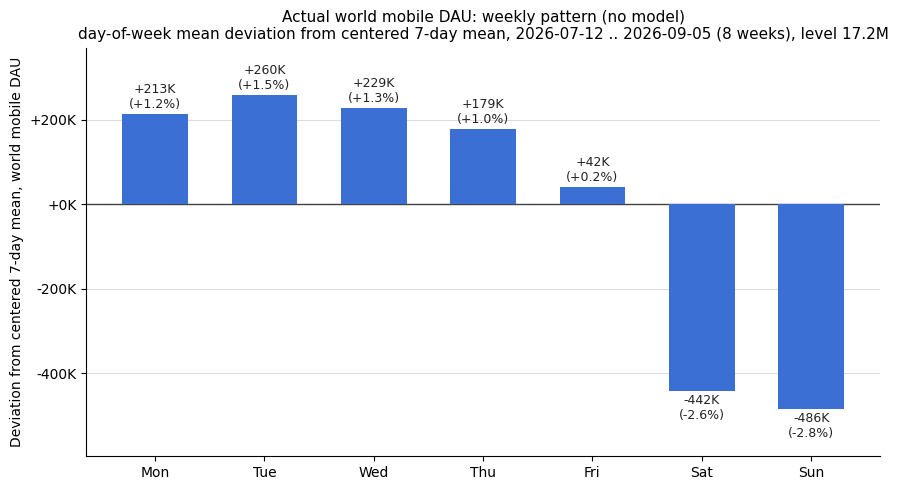

In [4]:
# [plot-actuals-weekly]
# Actuals only: day-of-week pattern of actual world mobile DAU (total, paid included)
# from the raw pull, no model.  Deviation from the centered 7-day rolling mean,
# averaged by day of week over the last ACTUALS_WEEKS whole weeks.
import pyarrow.parquet as pq

RAW_PULL_PATH = "mobile_rawpull_2026-09-09/mozaic_parts.raw.glean.mobile.DAU.parquet"
ACTUALS_END = pd.Timestamp("2026-09-05")            # last day with a full centered 7-day window (raw pull ends 2026-09-08)
ACTUALS_WEEKS = 8
ACTUALS_PLOT_PATH = "plots/mobile_weekly_seasonality_actuals_2026-09-05.png"

raw_table = pq.read_table(RAW_PULL_PATH)             # `x` is a BQ dbdate; cast via arrow, not pandas
raw_daily = pd.DataFrame({
    "date": pd.to_datetime(raw_table["x"].cast("string").to_pandas()),
    "dau": raw_table["y"].to_pandas(),
})
world_actuals = raw_daily.groupby("date")["dau"].sum().sort_index()

actuals_start = ACTUALS_END - pd.Timedelta(days=7 * ACTUALS_WEEKS - 1)
padded = world_actuals.loc[actuals_start - pd.Timedelta(days=3): ACTUALS_END + pd.Timedelta(days=3)]
deviation = (padded - padded.rolling(7, center=True).mean()).loc[actuals_start:ACTUALS_END]
assert deviation.notna().all() and len(deviation) == 7 * ACTUALS_WEEKS, (
    f"expected {7 * ACTUALS_WEEKS} complete days, got {deviation.notna().sum()}; "
    f"raw pull ends {world_actuals.index.max().date()}")
actuals_level = world_actuals.loc[actuals_start:ACTUALS_END].mean()
actuals_by_dow = deviation.groupby(deviation.index.dayofweek).mean().reindex(range(7))
actuals_by_dow.index = DOW_LABELS

print(f"Actuals {actuals_start.date()} .. {ACTUALS_END.date()} ({ACTUALS_WEEKS} whole weeks), "
      f"world mean level {actuals_level:,.0f} DAU")
for label, value in actuals_by_dow.items():
    print(f"  {label}  {value:>+12,.0f}   ({value / actuals_level:+.1%})")
print(f"mean over 7 day-of-week values: {actuals_by_dow.mean():>+12,.0f}")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(actuals_by_dow.index, actuals_by_dow.values, color="#3B6FD4", width=0.6, zorder=3)
ax.axhline(0, color="#444444", linewidth=1.0, zorder=2)
label_offset = 0.015 * np.abs(actuals_by_dow.values).max()
for bar, value in zip(bars, actuals_by_dow.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            value + (label_offset if value >= 0 else -label_offset),
            f"{value / 1e3:+.0f}K\n({value / actuals_level:+.1%})",
            ha="center", va="bottom" if value >= 0 else "top", fontsize=9, color="#222222")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e3:+.0f}K"))
ax.set_ylabel("Deviation from centered 7-day mean, world mobile DAU")
ax.set_title("Actual world mobile DAU: weekly pattern (no model)\n"
             f"day-of-week mean deviation from centered 7-day mean, {actuals_start.date()} .. {ACTUALS_END.date()} "
             f"({ACTUALS_WEEKS} weeks), level {actuals_level / 1e6:.1f}M",
             fontsize=11)
ax.grid(axis="y", color="#DDDDDD", zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(y=0.15)
fig.tight_layout()
fig.savefig(ACTUALS_PLOT_PATH, dpi=150)
print(f"saved {ACTUALS_PLOT_PATH}")
plt.show()
